In [1]:
import xarray as xr

zarr_path = "s3://noaa-oar-sfsdev-pds/experiments/beta1/forecast/202603/atm_monthly.zarr"

ds = xr.open_zarr(
    zarr_path,
    storage_options={"anon": True}
)

print(ds)

<xarray.Dataset> Size: 18GB
Dimensions:       (member: 31, lead: 12, lat: 361, lon: 720)
Coordinates:
  * member        (member) int64 248B 0 1 2 3 4 5 6 7 ... 24 25 26 27 28 29 30
  * lead          (lead) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * lat           (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 89.0 89.5 90.0
  * lon           (lon) float64 6kB 0.0 0.5 1.0 1.5 ... 358.0 358.5 359.0 359.5
Data variables: (12/46)
    acpcpsfc      (member, lead, lat, lon) float32 387MB ...
    apcpsfc       (member, lead, lat, lon) float32 387MB ...
    avg_ishfsfc   (member, lead, lat, lon) float32 387MB ...
    avg_slhtfsfc  (member, lead, lat, lon) float32 387MB ...
    avg_utauasfc  (member, lead, lat, lon) float32 387MB ...
    avg_vtauasfc  (member, lead, lat, lon) float32 387MB ...
    ...            ...
    vpot850       (member, lead, lat, lon) float32 387MB ...
    watrsfc       (member, lead, lat, lon) float32 387MB ...
    z200          (member, lead, lat, lon) float32 387MB ...
   

In [2]:
print(ds["land"].attrs)

{'short_name': 'LAND_surface', 'long_name': 'Land Cover (0=sea, 1=land)', 'level': 'surface', 'units': 'Proportion'}


In [3]:
# Select one member and one lead
land = ds["land"].isel(
    member=0,
    lead=0
)

print(land)

<xarray.DataArray 'land' (lat: 361, lon: 720)> Size: 1MB
[259920 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * lon      (lon) float64 6kB 0.0 0.5 1.0 1.5 2.0 ... 358.0 358.5 359.0 359.5
    lead     int64 8B 0
    member   int64 8B 0
Attributes:
    short_name:  LAND_surface
    long_name:   Land Cover (0=sea, 1=land)
    level:       surface
    units:       Proportion


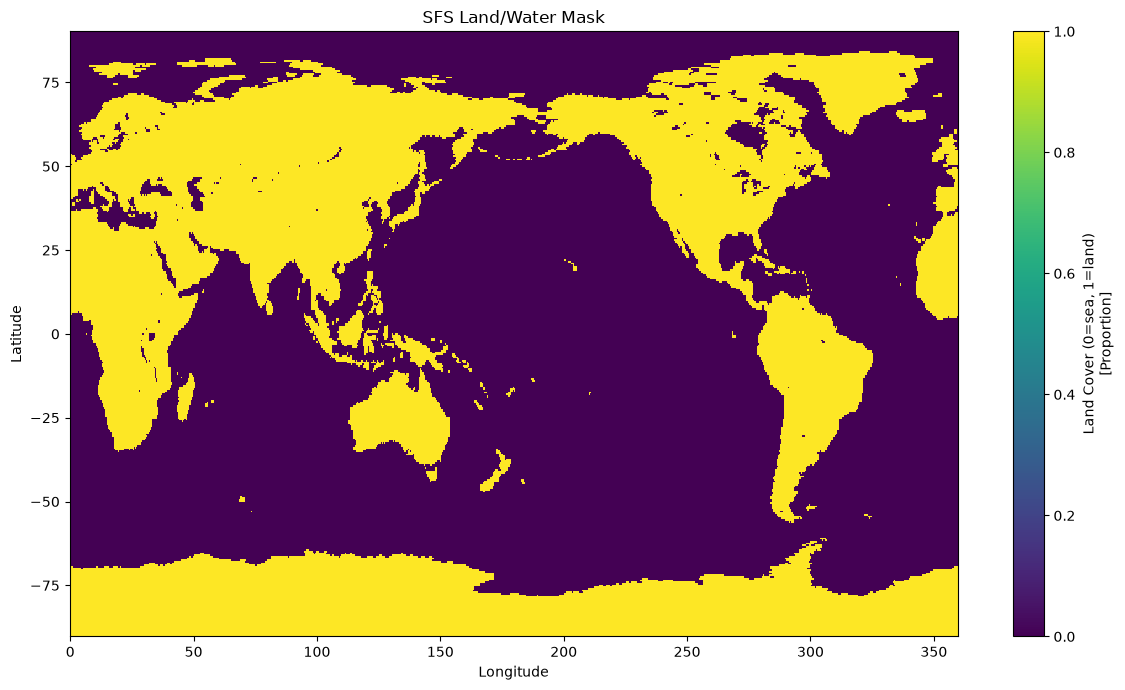

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))

land.plot(
    ax=ax,
    x="lon",
    y="lat"
)

ax.set_title("SFS Land/Water Mask")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

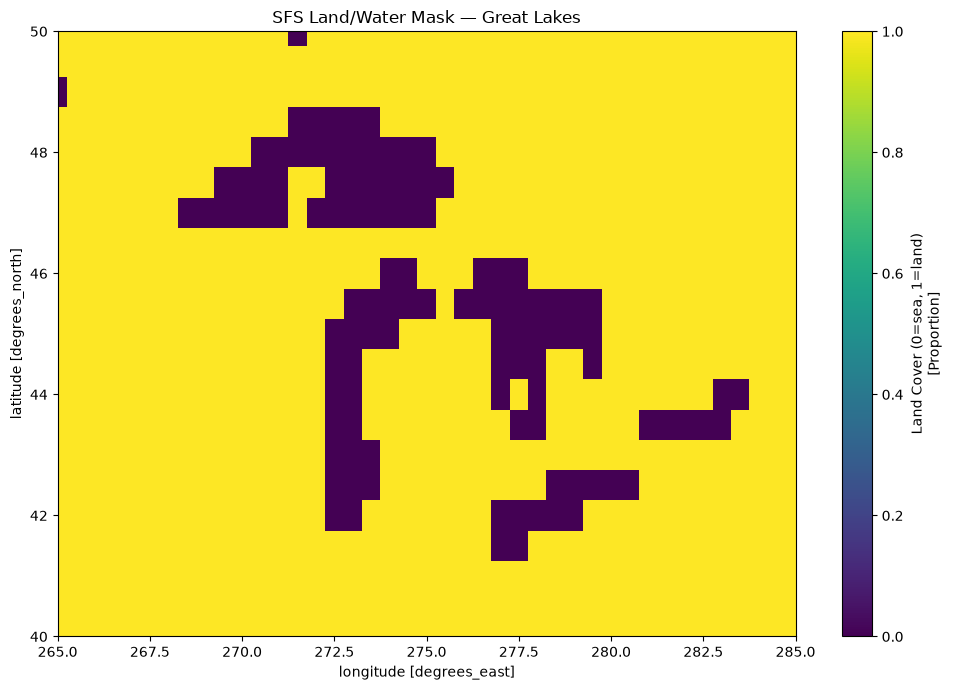

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

land.plot(ax=ax)

ax.set_xlim(265, 285)
ax.set_ylim(40, 50)

ax.set_title("SFS Land/Water Mask — Great Lakes")
plt.tight_layout()
plt.show()

/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


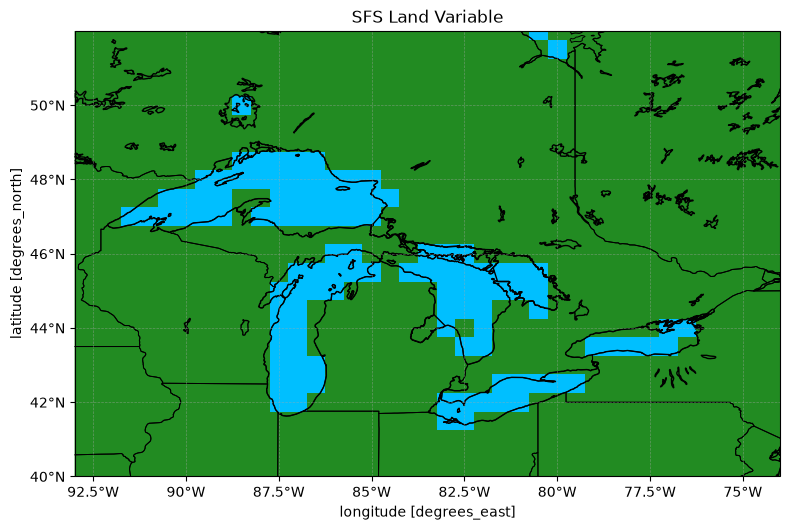

In [42]:
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import numpy as np

# ---------------------------------------------------------
# Custom colormap: water = blue, land = green
# ---------------------------------------------------------

cmap = mcolors.ListedColormap([
    "deepskyblue",   # 0 = water
    "forestgreen"  # 1 = land
])

norm = mcolors.BoundaryNorm(
    boundaries=[-0.5, 0.5, 1.5],
    ncolors=2
)

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig = plt.figure(figsize=(8, 12))

ax = plt.axes(projection=ccrs.PlateCarree())

land.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    add_colorbar=False,
    #cbar_kwargs={
    #    "ticks": [0, 1],
    #    "label": "Land / Water",
    #    "shrink": 0.7
    #}
)

ax.set_xticks(np.arange(-180, 180, 2.5), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(40, 52, 2), crs=ccrs.PlateCarree())

ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())

ax.grid(
    which="major",
    linestyle="--",
    linewidth=0.5,
    color="darkgray",
    alpha=0.5
)

# Great Lakes region
ax.set_extent([-93, -74, 40, 52], crs=ccrs.PlateCarree())

# State boundaries
ax.add_feature(
    cfeature.STATES,
    edgecolor="black",
    linewidth=0.7
)

# Lake outlines
ax.add_feature(
    cfeature.LAKES,
    edgecolor="black",
    facecolor="none",
    linewidth=1.0
)

# Coastlines
ax.coastlines(
    resolution="10m",
    linewidth=0.8
)

ax.set_title("SFS Land Variable")

plt.tight_layout()
plt.show()

/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


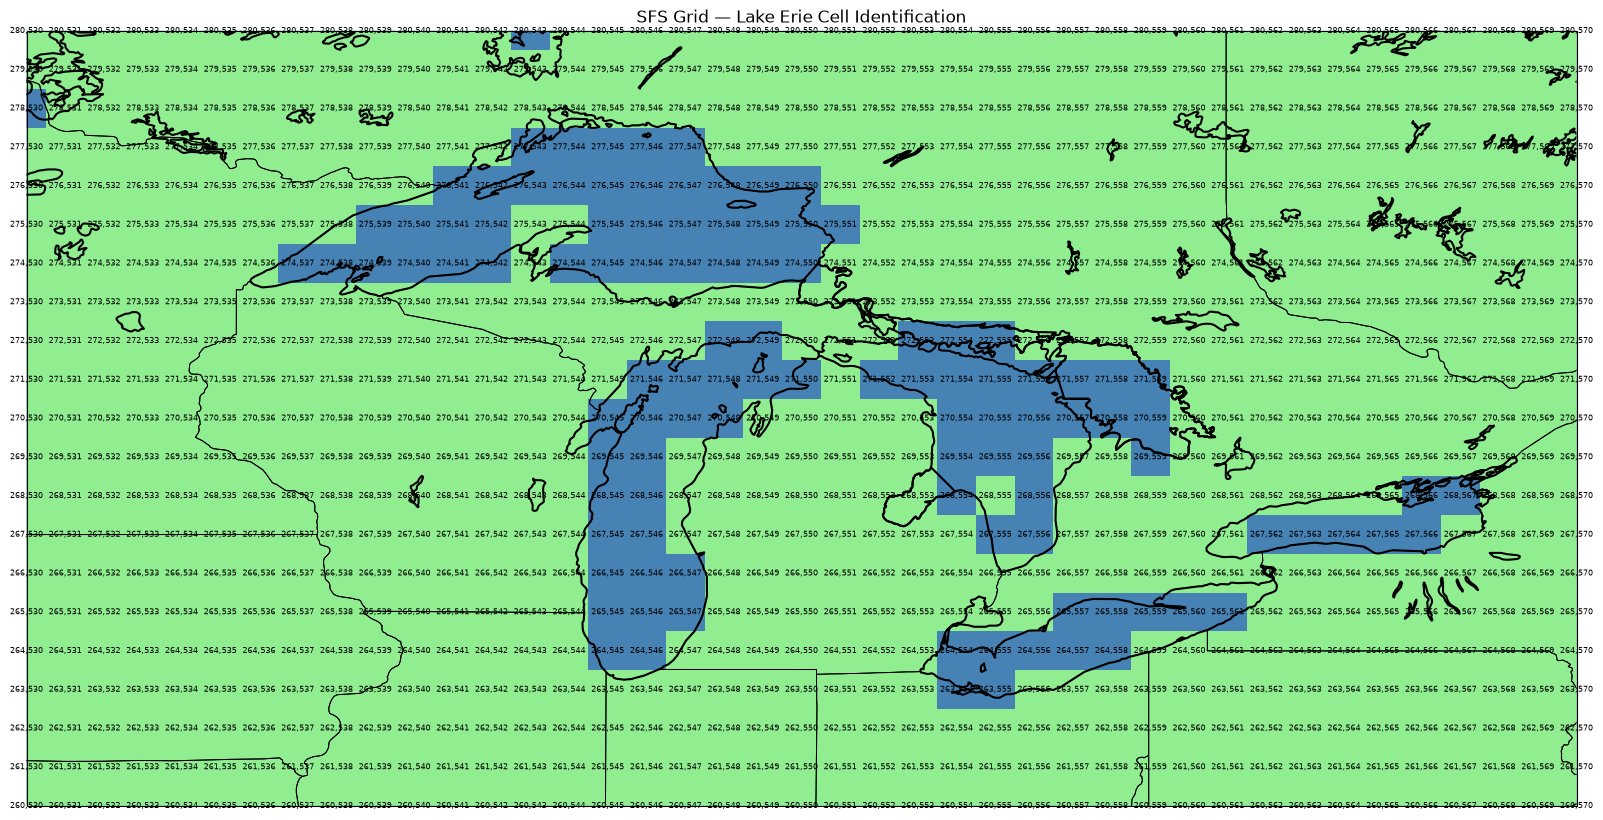

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

cmap = mcolors.ListedColormap([
    "steelblue",   # 0 = water
    "lightgreen"  # 1 = land
])

# Get coordinates
lat = land.lat.values
lon = land.lon.values

# Convert longitude to -180 to 180 for labeling
lon_180 = ((lon + 180) % 360) - 180

lon2d, lat2d = np.meshgrid(lon_180, lat)

# Create plot
fig = plt.figure(figsize=(20, 15))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot your existing Erie mask
ax.pcolormesh(
    lon_180,
    lat,
    land,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap=cmap
)

# Lake outline
ax.add_feature(
    cfeature.LAKES,
    facecolor="none",
    edgecolor="black",
    linewidth=1.5
)

ax.add_feature(
    cfeature.STATES,
    edgecolor="black",
    linewidth=0.7
)

ax.set_extent(
    [265-360, 285-360, 40, 50],
    crs=ccrs.PlateCarree()
)

# Label every grid point
for i in range(len(lat)):
    for j in range(len(lon)):

        if (
            265-360 <= lon_180[j] <= 285-360
            and 40 <= lat[i] <= 50
        ):
            ax.text(
                lon_180[j],
                lat[i],
                f"{i},{j}",
                fontsize=6,
                ha="center",
                va="center",
                transform=ccrs.PlateCarree(),
                zorder=10
            )

ax.set_title("SFS Grid — Lake Erie Cell Identification")

plt.show()

In [9]:
import cartopy.io.shapereader as shpreader
import geopandas as gpd

shp = shpreader.natural_earth(
    resolution="10m",
    category="physical",
    name="lakes"
)

reader = shpreader.Reader(shp)

lakes = list(reader.records())

for lake in lakes:
    name = lake.attributes.get("name")
    
    if name and any(
        x in name.lower()
        for x in ["superior", "michigan", "huron", "erie", "ontario"]
    ):
        print(name)

Lake Erie
Lake Ontario
Lake Superior
Lake Michigan
Lake Huron


In [10]:
lat = land.lat.values
lon = land.lon.values

print(lat.shape)
print(lon.shape)

(361,)
(720,)


In [11]:
lon_180 = ((lon + 180) % 360) - 180

In [12]:
from shapely import contains
from shapely import points

def polygon_to_grid_mask(geometry, lat, lon):

    lon_180 = ((lon + 180) % 360) - 180

    lon2d, lat2d = np.meshgrid(lon_180, lat)

    grid_points = points(
        lon2d.ravel(),
        lat2d.ravel()
    )

    mask = contains(
        geometry,
        grid_points
    )

    return mask.reshape(len(lat), len(lon))

In [14]:
erie_record = next(
    lake for lake in lakes
    if lake.attributes.get("name", "").lower() == "lake erie"
)

erie_geometry = erie_record.geometry

erie_lake = polygon_to_grid_mask(
    erie_geometry,
    lat,
    lon
)

print(erie_lake.shape)
print(np.unique(erie_lake))

(361, 720)
[False  True]


/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


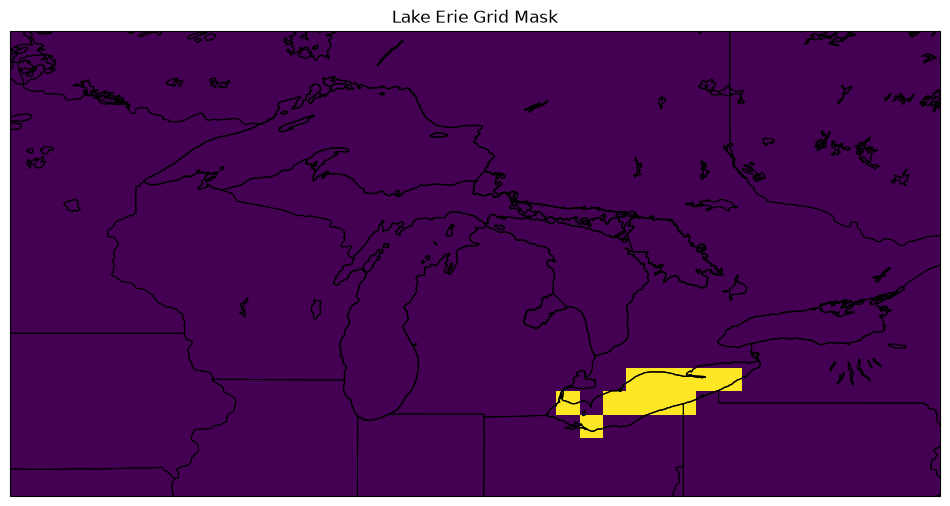

In [15]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(12, 8))

ax = plt.axes(
    projection=ccrs.PlateCarree()
)

ax.pcolormesh(
    lon,
    lat,
    erie_lake,
    transform=ccrs.PlateCarree(),
    shading="auto"
)

ax.set_extent(
    [265, 285, 40, 50],
    crs=ccrs.PlateCarree()
)

ax.add_feature(
    cfeature.STATES,
    edgecolor="black",
    linewidth=0.7
)

ax.add_feature(
    cfeature.LAKES,
    facecolor="none",
    edgecolor="black",
    linewidth=1
)

ax.coastlines(resolution="10m")

ax.set_title("Lake Erie Grid Mask")

plt.show()

In [16]:
from shapely import covers, points

def polygon_to_grid_mask(geometry, lat, lon):

    lon_180 = ((lon + 180) % 360) - 180

    lon2d, lat2d = np.meshgrid(lon_180, lat)

    grid_points = points(
        lon2d.ravel(),
        lat2d.ravel()
    )

    mask = covers(
        geometry,
        grid_points
    )

    return mask.reshape(len(lat), len(lon))

In [17]:
erie_lake = polygon_to_grid_mask(
    erie_geometry,
    lat,
    lon
)

In [18]:
water = land == 0

erie_lake = (
    polygon_to_grid_mask(erie_geometry, lat, lon)
    & water.values
)

/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


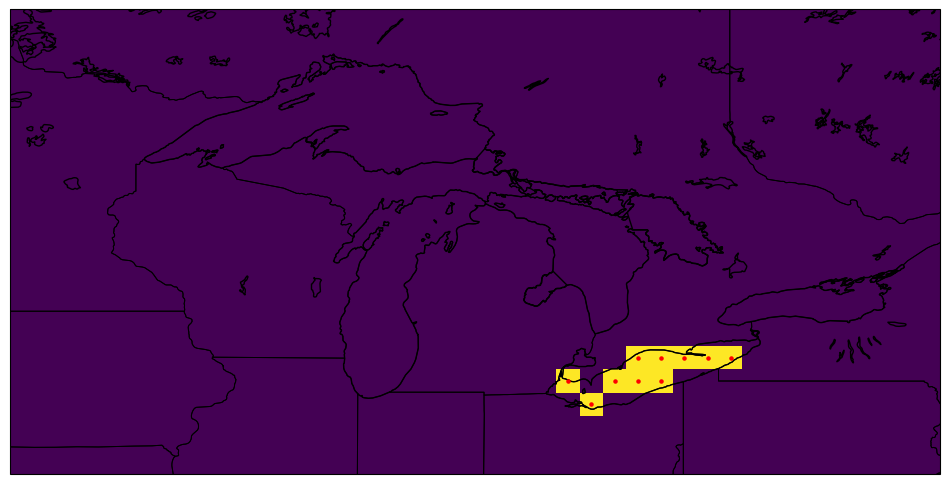

In [19]:
fig = plt.figure(figsize=(12, 8))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.pcolormesh(
    lon,
    lat,
    erie_lake,
    transform=ccrs.PlateCarree(),
    shading="auto"
)

# Plot the actual grid points
lon2d, lat2d = np.meshgrid(lon, lat)

ax.scatter(
    lon2d[erie_lake],
    lat2d[erie_lake],
    s=5,
    color="red",
    transform=ccrs.PlateCarree(),
    zorder=5
)

ax.set_extent(
    [265, 285, 40, 50],
    crs=ccrs.PlateCarree()
)

ax.add_feature(
    cfeature.STATES,
    edgecolor="black",
    linewidth=0.7
)

ax.add_feature(
    cfeature.LAKES,
    facecolor="none",
    edgecolor="black",
    linewidth=1
)

ax.coastlines(resolution="10m")

plt.show()

/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


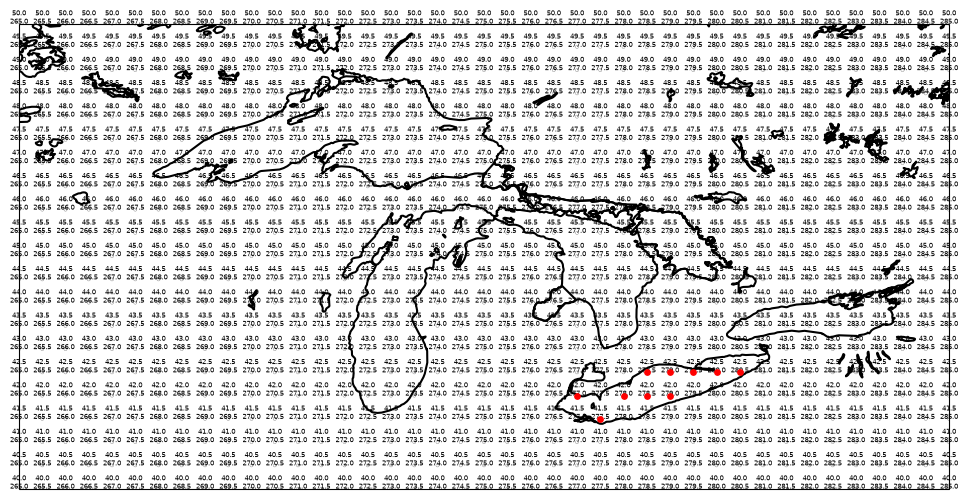

In [21]:
fig = plt.figure(figsize=(12, 8))

ax = plt.axes(projection=ccrs.PlateCarree())

# Plot all SFS grid points
lon2d, lat2d = np.meshgrid(lon, lat)

ax.scatter(
    lon2d,
    lat2d,
    s=5,
    facecolors="none",
    edgecolors="gray",
    linewidths=0.3,
    transform=ccrs.PlateCarree()
)

# Plot selected Erie points
ax.scatter(
    lon2d[erie_lake],
    lat2d[erie_lake],
    s=15,
    color="red",
    transform=ccrs.PlateCarree(),
    zorder=5
)

# Lake boundary
ax.add_feature(
    cfeature.LAKES,
    facecolor="none",
    edgecolor="black",
    linewidth=1.5
)

ax.set_extent(
    [265, 285, 40, 50],
    crs=ccrs.PlateCarree()
)

for i in range(len(lat)):
    for j in range(len(lon)):

        if 265 <= lon[j] <= 285 and 40 <= lat[i] <= 50:

            ax.text(
                lon[j],
                lat[i],
                f"{lat[i]:.1f}\n{lon[j]:.1f}",
                fontsize=5,
                ha="center",
                transform=ccrs.PlateCarree()
            )
plt.show()